In [1]:
from scipy import sparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import os
import seaborn as sns
import time

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import umap as up

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from tools import plot_3D, plot_the_PCA_interval, plot_clusters

os.environ["MKL_THREADING_LAYER"] = "GNU"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
RANDOM_SEED = 42

In [2]:
X = sparse.load_npz("../datasets/clusterization/train.npz")
M, N = X.shape
# масштабируем
scaler = RobustScaler(with_centering=False)
X_scaled = scaler.fit_transform(X)
# PCA
pca_new = PCA(n_components=40)
X_embedded_pca = pca_new.fit_transform(X_scaled)

### <div align="center">Elbew analyze</div>
С помощью k-MEANS ищу оптимальное количество кластеров и X_embedded_pca

c:\Users\user_1\miniforge3\envs\ipynb_base\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


model 0 ready
Time elapsed(in general): 7.923628807067871
model 1 ready
Time elapsed(in general): 13.410532712936401
model 2 ready
Time elapsed(in general): 18.80265712738037
model 3 ready
Time elapsed(in general): 24.062103748321533
model 4 ready
Time elapsed(in general): 29.503987073898315
model 5 ready
Time elapsed(in general): 34.743767499923706
model 6 ready
Time elapsed(in general): 39.80588340759277
model 7 ready
Time elapsed(in general): 45.01471304893494
model 8 ready
Time elapsed(in general): 49.888895750045776
model 9 ready
Time elapsed(in general): 54.7501060962677
model 10 ready
Time elapsed(in general): 59.57413101196289
model 11 ready
Time elapsed(in general): 64.31125116348267
model 12 ready
Time elapsed(in general): 69.01176285743713
model 13 ready
Time elapsed(in general): 73.7878532409668
model 14 ready
Time elapsed(in general): 78.58526086807251
model 15 ready
Time elapsed(in general): 84.16021776199341
model 16 ready
Time elapsed(in general): 90.05674886703491
mode

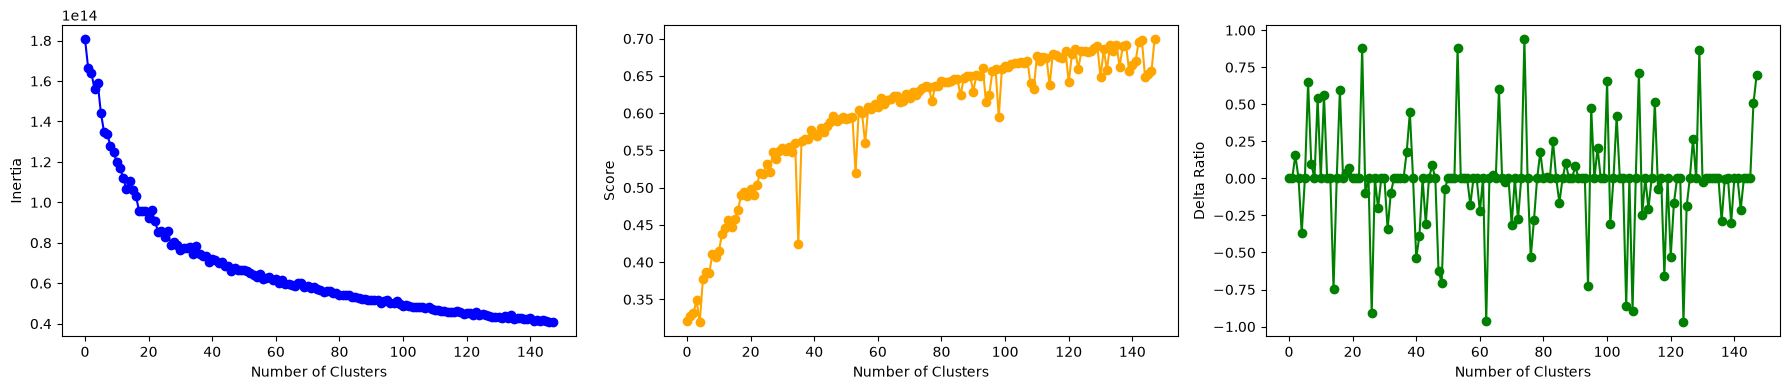

In [3]:
a = 2
b = 150
ln = b-a
loss_hist = np.zeros((ln))
silhouette_hist = np.zeros((ln))
delta_ratio_loss_hist = np.zeros((ln))
delta_loss_hist = np.zeros((ln))

start = time.time()
ind = 0
for k in range(a, b):   
    kmeans = KMeans(n_clusters=k).fit(X_embedded_pca)
    loss_hist[ind] = kmeans.inertia_
    if ind == 0:
        delta_loss_hist[ind] = 0
        delta_ratio_loss_hist[ind] = 0
    elif ind == 1:
        delta_loss_hist[ind] = loss_hist[ind-1] - loss_hist[ind]
        delta_ratio_loss_hist[ind] = 0
    else:
        delta_loss_hist[ind] = loss_hist[ind-1] - loss_hist[ind]
        temp = delta_loss_hist[ind]/delta_loss_hist[ind-1]
        if abs(temp) > 1: delta_ratio_loss_hist[ind] = 0
        else: delta_ratio_loss_hist[ind] = temp

    labels = kmeans.labels_
    silhouette_hist[ind] = silhouette_score(X_embedded_pca, labels, random_state=RANDOM_SEED)
    print(f"model {ind} ready\nTime elapsed(in general): {time.time()-start}")
    ind += 1

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(loss_hist, marker='o', color="blue")
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax2.plot(silhouette_hist, marker='o', color='orange')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Score')
ax3.plot(delta_ratio_loss_hist, marker='o', color='green')
ax3.set_xlabel('Number of Clusters')
ax3.set_ylabel('Delta Ratio')

plt.tight_layout()
plt.show()

#### Conclusion
Можно рассматривать примрерно 70-100 кластеров